Name: Dhruv Garg

Roll No: 8025320034

Q1. You are a data analyst at an e-commerce company. Your task is to analyze sales data, clean and process it, perform statistical analysis, and generate visual insights to help the business make informed decisions.

In [ ]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Part I: Randomized Sales Data Generation (NumPy)

In [ ]:
#Using Roll No as seed value to generate unique data
Roll_No = 34
np.random.seed(Roll_No)

Step 2: Generate Random Sales Data

A NumPy array of shape (12, 4) is created to represent monthly sales for 12 months across 4 product categories:

Electronics
Clothing
Home & Kitchen
Sports

In [ ]:
#Step 2: Generating Random Sales Data
# Sales values between 1000 and 5000 units per month
sales_data = np.random.randint(1000, 5001, size=(12, 4))
print(sales_data)
print(f"\nShape: {sales_data.shape}")

[[4489 2146 3538 2897]
 [4830 4157 1324 2571]
 [3501 2675 2514 4278]
 [3717 4602 2565 3649]
 [1248 3845 1614 1373]
 [3166 3324 4680 1830]
 [2285 1916 2971 4603]
 [1981 4861 3239 3536]
 [4656 1495 4626 1365]
 [4540 1328 1894 3154]
 [2101 3212 4714 2317]
 [3274 2210 3986 4275]]

Shape: (12, 4)


Step 3: Convert NumPy Array to Pandas DataFrame

The NumPy array is converted into a Pandas DataFrame with:

Columns as product categories

Index as months from January to December

In [ ]:
#Step 3: Converting to Pandas DataFrame
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']

df = pd.DataFrame(sales_data, index=months, columns=categories)

print("Sales Dataframe: ")
print(df)

Sales Dataframe: 
     Electronics  Clothing  Home & Kitchen  Sports
Jan         4489      2146            3538    2897
Feb         4830      4157            1324    2571
Mar         3501      2675            2514    4278
Apr         3717      4602            2565    3649
May         1248      3845            1614    1373
Jun         3166      3324            4680    1830
Jul         2285      1916            2971    4603
Aug         1981      4861            3239    3536
Sep         4656      1495            4626    1365
Oct         4540      1328            1894    3154
Nov         2101      3212            4714    2317
Dec         3274      2210            3986    4275


Part II: Data Manipulation and Analysis (Pandas)

Step 1: Display First 5 Rows and Summary Statistics

The first 5 rows help inspect the data structure, and summary statistics provide information such as count, mean, standard deviation, minimum, quartiles, and maximum values.

In [ ]:
#Step 1: First 5 Rows & Summary Statistics
print("First 5 Rows: ")
print(df.head())
print("\nSummary Statistics: ")
print(df.describe())

First 5 Rows: 
     Electronics  Clothing  Home & Kitchen  Sports
Jan         4489      2146            3538    2897
Feb         4830      4157            1324    2571
Mar         3501      2675            2514    4278
Apr         3717      4602            2565    3649
May         1248      3845            1614    1373

Summary Statistics: 
       Electronics     Clothing  Home & Kitchen       Sports
count    12.000000    12.000000       12.000000    12.000000
mean   3315.666667  2980.916667     3138.750000  2987.333333
std    1197.695692  1203.126794     1201.184425  1124.487708
min    1248.000000  1328.000000     1324.000000  1365.000000
25%    2239.000000  2088.500000     2359.000000  2195.250000
50%    3387.500000  2943.500000     3105.000000  3025.500000
75%    4501.750000  3923.000000     4146.000000  3805.500000
max    4830.000000  4861.000000     4714.000000  4603.000000


Step 2: Calculate Total Sales

Two types of totals are calculated:

Total sales per category
Total sales per month

In [ ]:
#Step 2: Total Sales per Category & per Month
#Sum down each column
total_per_category = df.sum(axis=0)
#Sum across each row
total_per_month = df.sum(axis=1)
print("Total Sales per Category: ")
print(total_per_category)
print("\nTotal Sales per Month: ")
print(total_per_month)

Total Sales per Category: 
Electronics       39788
Clothing          35771
Home & Kitchen    37665
Sports            35848
dtype: int64

Total Sales per Month: 
Jan    13070
Feb    12882
Mar    12968
Apr    14533
May     8080
Jun    13000
Jul    11775
Aug    13617
Sep    12142
Oct    10916
Nov    12344
Dec    13745
dtype: int64


Step 3: Calculate Average Sales Growth Between Consecutive Months

The percentage change between consecutive months is calculated for each category using pct_change(). Then, the average growth rate is computed for each category.

In [ ]:
# Step 3: Average Sales Growth between Consecutive Months
# multiply pct_change() value by 100 to get percentage change
monthly_growth = df.pct_change()*100
avg_growth = monthly_growth.mean()
print("Monthly Growth Rate per Category: ")
print(monthly_growth)
print("\nAverage Growth Rate per Category: ")
print(avg_growth)



Monthly Growth Rate per Category: 
     Electronics    Clothing  Home & Kitchen      Sports
Jan          NaN         NaN             NaN         NaN
Feb     7.596347   93.709226      -62.577728  -11.253020
Mar   -27.515528  -35.650710       89.879154   66.394399
Apr     6.169666   72.037383        2.028640  -14.703132
May   -66.424536  -16.449370      -37.076023  -62.373253
Jun   153.685897  -13.550065      189.962825   33.284778
Jul   -27.826911  -42.358604      -36.517094  151.530055
Aug   -13.304158  153.705637        9.020532  -23.180534
Sep   135.032812  -69.245011       42.821859  -61.397059
Oct    -2.491409  -11.170569      -59.057501  131.062271
Nov   -53.722467  141.867470      148.891235  -26.537730
Dec    55.830557  -31.195517      -15.443360   84.505826

Average Growth Rate per Category: 
Electronics       15.184570
Clothing          21.972716
Home & Kitchen    24.721140
Sports            24.302964
dtype: float64


Step 4: Add Total Sales and Growth Rate Columns

Following two new columns are added to the dataframe:

Total Sales: Sum of all category sales for each month

Growth Rate: Percentage change in total monthly sales compared to the previous month

In [ ]:
# Step 4: Add 'Total Sales' and 'Growth Rate' Columns
df['Total Sales'] = df[categories].sum(axis=1)
df['Growth Rate'] = df['Total Sales'].pct_change()*100

print("DataFrame with New Columns: ")
print(df)

DataFrame with New Columns: 
     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         4489      2146            3538    2897        13070          NaN
Feb         4830      4157            1324    2571        12882    -1.438409
Mar         3501      2675            2514    4278        12968     0.667598
Apr         3717      4602            2565    3649        14533    12.068168
May         1248      3845            1614    1373         8080   -44.402395
Jun         3166      3324            4680    1830        13000    60.891089
Jul         2285      1916            2971    4603        11775    -9.423077
Aug         1981      4861            3239    3536        13617    15.643312
Sep         4656      1495            4626    1365        12142   -10.832048
Oct         4540      1328            1894    3154        10916   -10.097183
Nov         2101      3212            4714    2317        12344    13.081715
Dec         3274      2210            3986    4

Step 5: Apply Discount Based on Roll Number:

Even roll number → 10% discount on Electronics

Odd roll number → 15% discount on Clothing

In [ ]:
#Step 5: Apply Randomized Discount Based on Roll Number
#Roll Number is Even (34) → Apply 10% discount to Clothing

if Roll_No % 2 == 0:
    df['Electronics'] = df['Electronics'] * 0.90   # 10% discount
    print(f"Roll number {Roll_No} is EVEN → 10% discount applied to Electronics")
else:
    df['Clothing'] = df['Clothing'] * 0.85         # 15% discount
    print(f"Roll number {Roll_No} is ODD → 15% discount applied to Clothing")

print("\n DataFrame After Discount: ")
print(df)

Roll number 34 is EVEN → 10% discount applied to Electronics

 DataFrame After Discount: 
     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan       4040.1      2146            3538    2897        13070          NaN
Feb       4347.0      4157            1324    2571        12882    -1.438409
Mar       3150.9      2675            2514    4278        12968     0.667598
Apr       3345.3      4602            2565    3649        14533    12.068168
May       1123.2      3845            1614    1373         8080   -44.402395
Jun       2849.4      3324            4680    1830        13000    60.891089
Jul       2056.5      1916            2971    4603        11775    -9.423077
Aug       1782.9      4861            3239    3536        13617    15.643312
Sep       4190.4      1495            4626    1365        12142   -10.832048
Oct       4086.0      1328            1894    3154        10916   -10.097183
Nov       1890.9      3212            4714    2317        12344

Part III: Visualizations (Matplotlib and Seaborn)

Step 1: Monthly Sales Trends (Line Plot)

A line plot is created to visualize monthly sales trends for each product category across the year.

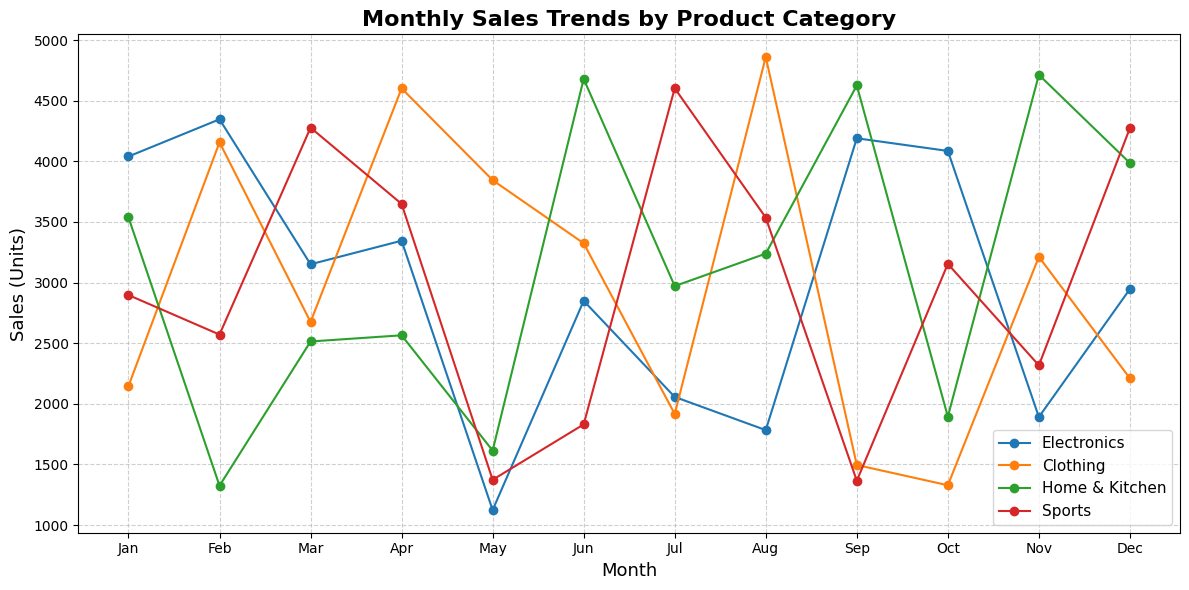

In [ ]:
# Plot 1: Monthly Sales Trends
plt.figure(figsize=(12, 6))

for category in categories:
    plt.plot(months, df[category], marker='o', label=category)

plt.title('Monthly Sales Trends by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Sales (Units)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Step 2: Box Plot for Sales Distribution

A box plot is used to show the distribution of sales values for each category

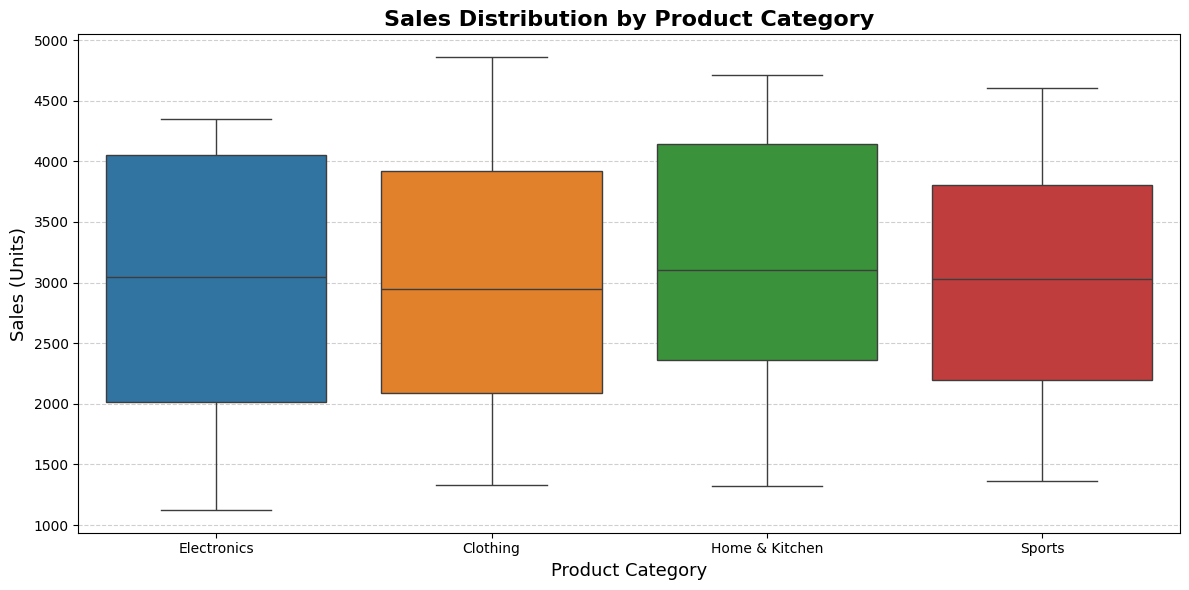

In [ ]:
#Plot 2: Box Plots - Sales Distribution per Category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[categories])
plt.title('Sales Distribution by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=13)
plt.ylabel('Sales (Units)', fontsize=13)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])

i. Find element-wise absolute value

ii. Find the 25th, 50th, and 75th percentile of flattened array, for each column, for each row.

iii. Mean, Median and Standard Deviation of flattened array, of each column, and each row.

In [ ]:
array = np.array([[1,-2,3], [-4, 5, -6]])
print("Original Array: ")
print(array)

Original Array: 
[[ 1 -2  3]
 [-4  5 -6]]


In [ ]:
# i. Elementwise Absolute Value
abs_array = np.abs(array)
print("Elementwise Absolute Value: ")
print(abs_array)

Elementwise Absolute Value: 
[[1 2 3]
 [4 5 6]]


In [ ]:
# ii. 25th, 50th, and 75th Percentile
flattened_array = array.flatten()
Percentiles = [25, 50, 75]
print("Percentiles of Flattened Array: ")
print(np.percentile(flattened_array, Percentiles))

print("Percentiles for Each Column: ")
print(np.percentile(array, Percentiles, axis=0))

print("Percentiles for Each Row: ")
print(np.percentile(array, Percentiles, axis=1))


Percentiles of Flattened Array: 
[-3.5 -0.5  2.5]
Percentiles for Each Column: 
[[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]
Percentiles for Each Row: 
[[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]


In [ ]:
# iii. Mean, Median, Standard Deviation
print("Flattened Array: ")
print(f"Mean: {np.mean(flattened_array):.4f}")
print(f"Median: {np.median(flattened_array):.4f}")
print(f"Standard Deviation: {np.std(flattened_array):.4f}")

print("\nEach Column: ")
print(f"Mean: {np.mean(array, axis=0)}")
print(f"Median: {np.median(array, axis=0)}")
print(f"Standard Deviation: {np.std(array, axis=0)}")

print("\nEach Row: ")
print(f"Mean: {np.mean(array, axis=1)}")
print(f"Median: {np.median(array, axis=1)}")
print(f"Standard Deviation: {np.std(array, axis=1)}")


Flattened Array: 
Mean: -0.5000
Median: -0.5000
Standard Deviation: 3.8622

Each Column: 
Mean: [-1.5  1.5 -1.5]
Median: [-1.5  1.5 -1.5]
Standard Deviation: [2.5 3.5 4.5]

Each Row: 
Mean: [ 0.66666667 -1.66666667]
Median: [ 1. -4.]
Standard Deviation: [2.05480467 4.78423336]


Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).

i. Find floor, ceiling and truncated value, rounded values

In [ ]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Original Array: ")
print(a)

print("\nFloor Values: ")
# Rounds Down to nearest integer
print(np.floor(a))

print("\nCeiling Values: ")
# Rounds Up to nearest integer
print(np.ceil(a))

print("\nTruncated Values: ")
# Removes decimal part
print(np.trunc(a))

print("\nRounded Values: ")
# Rounds to nearest even integer
print(np.round(a))

Original Array: 
[-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]

Floor Values: 
[-2. -2. -1.  0.  1.  1.  3.]

Ceiling Values: 
[-1. -1. -0.  1.  2.  2.  3.]

Truncated Values: 
[-1. -1. -0.  0.  1.  1.  3.]

Rounded Values: 
[-2. -2. -0.  0.  2.  2.  3.]


Q.4 WAP to swap two elements in a list in Python Using a Temporary Variable.

In [ ]:
# Swap elements in a list using a temporary variable
my_list = [10, 20, 30, 40, 50]
print(f"Original List: {my_list}")

# Positions to swap index 1 (value=20) and index 3 (value=40)
i = 1
j = 3

# Save element at index i into a temporary variable
temp = my_list[i]

# Place element at index j into index i
my_list[i] = my_list[j]

# Place the saved temp value into index j
my_list[j] = temp

print(f"List after swapping index {i} and {j}: {my_list}")

Original List: [10, 20, 30, 40, 50]
List after swapping index 1 and 3: [10, 40, 30, 20, 50]


Q.5 Write a Python program to swap two elements in a set by converting it to a list first.

In [ ]:
# Swap elements in a set by converting to a list first

my_set = {10, 20, 30, 40, 50}
print(f"Original Set: {my_set}")

#Convert set to list
temp_list = list(my_set)
print(f"Set converted to List: {temp_list}")

#Swap elements at index 0 and index 2 using temp variable
i = 0
j = 2

temp = temp_list[i]
temp_list[i] = temp_list[j]
temp_list[j] = temp

print(f"List after swapping index {i} and {j}: {temp_list}")

# Converting back to set
my_set = set(temp_list)
print(f"Converted back to Set: {my_set}")

Original Set: {50, 20, 40, 10, 30}
Set converted to List: [50, 20, 40, 10, 30]
List after swapping index 0 and 2: [40, 20, 50, 10, 30]
Converted back to Set: {40, 10, 50, 20, 30}
